# Conditional Diffusion Training

This notebook uses the project code directly instead of duplicating path, dataset, and training logic. Training images are read from `data/images/<run-id>/message.png`, and condition labels are read from the matching `output/json/**/<run-id>.json` at `Logs/4th Step`.
The example config uses `fit_mode="height-flatten"` to use the `ImgConfig.img_size` height as the unit, flatten ImgConfig-sized blocks, and then reshape to a square RGB image; the source dimensions must be multiples of `ImgConfig.img_size` (28x28 by default). `reshape` remains available for equal-area square conversion.

Label mapping:
- input image: `data/images/<run-id>/message.png`
- condition label: `output/json/**/<run-id>.json` -> `Logs/4th Step`


## Imports

The only manual bootstrap here is a fallback for running the notebook before `pip install -e .`. After that, project paths come from `OutputConfig`, and training parameters come from `ConditionalDiffusionTrainConfig`.

In [1]:
from dataclasses import asdict, replace
from pathlib import Path
import json
import sys


def add_local_src_to_path() -> Path:
    current = Path.cwd().resolve()
    for candidate in (current, *current.parents):
        src = candidate / "src"
        if (candidate / "pyproject.toml").exists() and (src / "diffusion_hash_inv").exists():
            if str(src) not in sys.path:
                sys.path.insert(0, str(src))
            return candidate
    raise RuntimeError("Project root with src/diffusion_hash_inv was not found.")


try:
    from diffusion_hash_inv.config import OutputConfig
except ModuleNotFoundError:
    add_local_src_to_path()
    from diffusion_hash_inv.config import OutputConfig

import torch
from IPython.display import display
from PIL import Image

from diffusion_hash_inv.models.conditional_diffusion import (
    ConditionalDiffusionTrainConfig,
    GeneratedImageDataset,
    cleanup_torch_resources,
    save_image_grid,
    train_conditional_diffusion,
)


## Project Paths

`OutputConfig` is the codebase-level source of truth for the project root and output directories.

In [2]:
output_cfg = OutputConfig()

DATA_ROOT = output_cfg.data_dir / "images"
JSON_ROOT = output_cfg.output_dir / "json"
NOTEBOOK_OUTPUT_DIR = output_cfg.output_dir / "conditional_diffusion_notebook"

assert DATA_ROOT.exists(), DATA_ROOT
assert JSON_ROOT.exists(), JSON_ROOT
NOTEBOOK_OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

print(output_cfg)
print("Image root:", DATA_ROOT)
print("JSON root:", JSON_ROOT)
print("Notebook output:", NOTEBOOK_OUTPUT_DIR)


OutputConfig
  Root Directory: /Users/choisoonwook/Experiments_local/Diffusion_HASH_inverse,
  Data Directory: /Users/choisoonwook/Experiments_local/Diffusion_HASH_inverse/data,
  Output Directory: /Users/choisoonwook/Experiments_local/Diffusion_HASH_inverse/output,
  EMNIST Directory: /Users/choisoonwook/Experiments_local/Diffusion_HASH_inverse/EMNIST,
  Encoding: 'utf-8'

Image root: /Users/choisoonwook/Experiments_local/Diffusion_HASH_inverse/data/images
JSON root: /Users/choisoonwook/Experiments_local/Diffusion_HASH_inverse/output/json
Notebook output: /Users/choisoonwook/Experiments_local/Diffusion_HASH_inverse/output/conditional_diffusion_notebook


## Training Config

All parameters are collected in `ConditionalDiffusionTrainConfig`. The smoke config is intentionally small so the full pipeline can be verified quickly.
With `fit_mode="height-flatten"`, input images use the `ImgConfig.img_size` height as the unit, flatten ImgConfig-sized blocks, and reshape to a square RGB image. `reshape` is still available for equal-area square conversion.
When process traces are enabled, forward traces are saved for every diffusion timestep; `trace_steps` controls reverse trace sampling only.

For custom beta schedules, set `beta_schedule` to `file`, `hash-approach1`, or `hash-approach2`. Use `beta_values_path` with `file`.

In [3]:
smoke_config = ConditionalDiffusionTrainConfig(
    data_root=DATA_ROOT,
    json_root=JSON_ROOT,
    output_dir=NOTEBOOK_OUTPUT_DIR / "smoke",
    image_size=32,
    channels=3,
    fit_mode="height-flatten",
    max_images=256,
    batch_size=8,
    train_steps=3,
    epochs=None,
    timesteps=4,
    learning_rate=2e-4,
    base_channels=8,
    time_dim=16,
    beta_schedule="hash-approach1",
    sample_count=1,
    save_process_traces=True,
    trace_sample_count=1,
    # trace_steps is compatibility-only; reverse traces are saved for all timesteps.
    trace_steps=4,
    save_train_batches_every=5,
    device="cpu",
    log_every=1,
)

asdict(smoke_config)


{'data_root': PosixPath('/Users/choisoonwook/Experiments_local/Diffusion_HASH_inverse/data/images'),
 'json_root': PosixPath('/Users/choisoonwook/Experiments_local/Diffusion_HASH_inverse/output/json'),
 'output_dir': PosixPath('/Users/choisoonwook/Experiments_local/Diffusion_HASH_inverse/output/conditional_diffusion_notebook/smoke'),
 'image_size': 32,
 'channels': 3,
 'fit_mode': 'height-flatten',
 'condition_mode': 'json-step',
 'max_images': 256,
 'batch_size': 8,
 'train_steps': 3,
 'epochs': None,
 'timesteps': 4,
 'learning_rate': 0.0002,
 'base_channels': 8,
 'time_dim': 16,
 'beta_start': 0.0001,
 'beta_end': 0.02,
 'beta_schedule': 'hash-approach1',
 'beta_values_path': None,
 'beta_schedule_step': '4th Step',
 'device': 'cpu',
 'seed': 0,
 'num_workers': 0,
 'log_every': 1,
 'sample_every': 0,
 'checkpoint_every': 0,
 'sample_count': 1,
 'save_process_traces': True,
 'trace_sample_count': 1,
 'trace_steps': 4,
 'save_train_batches_every': 5}

## Dataset Preview

`GeneratedImageDataset` uses the same config fields as the trainer. This preview confirms `message.png`-only sampling and `Logs/4th Step` labels before training starts.

In [4]:
def dataset_from_config(config: ConditionalDiffusionTrainConfig) -> GeneratedImageDataset:
    return GeneratedImageDataset(
        config.data_root,
        json_root=config.json_root,
        image_size=config.image_size,
        channels=config.channels,
        fit_mode=config.fit_mode,
        max_images=config.max_images,
    )


dataset = dataset_from_config(smoke_config)
print("dataset size:", len(dataset))
print("num conditions:", dataset.num_conditions)

for sample in dataset.samples[:10]:
    relative_path = sample.path.relative_to(smoke_config.data_root)
    preview = sample.condition if len(sample.condition) <= 120 else sample.condition[:120] + "..."
    print(f"label={sample.label:03d} path={relative_path} condition={preview}")


dataset size: 256
num conditions: 256
label=131 path=MD5_2048_2026-05-10 02-44-31_000/message.png condition={"1st Round":{"10th Loop":{"A":"0x7bd87f68","B":"0xdec1058a","C":"0x4decbfca","D":"0x8da88f4a"},"11th Loop":{"A":"0x8da8...
label=034 path=MD5_2048_2026-05-10 02-44-31_001/message.png condition={"1st Round":{"10th Loop":{"A":"0x1fb6b5d2","B":"0xcbee32e5","C":"0xd14d9bc5","D":"0xda420f80"},"11th Loop":{"A":"0xda42...
label=101 path=MD5_2048_2026-05-10 02-44-31_002/message.png condition={"1st Round":{"10th Loop":{"A":"0x626ecaae","B":"0x1bce2b79","C":"0x97d72dfb","D":"0x36408099"},"11th Loop":{"A":"0x3640...
label=095 path=MD5_2048_2026-05-10 02-44-31_003/message.png condition={"1st Round":{"10th Loop":{"A":"0x5bce0e30","B":"0x470e58bc","C":"0x7ab45dbb","D":"0x78b80221"},"11th Loop":{"A":"0x78b8...
label=063 path=MD5_2048_2026-05-10 02-44-31_004/message.png condition={"1st Round":{"10th Loop":{"A":"0x3da3a48e","B":"0x9c8aebf5","C":"0x9b52dfb3","D":"0x72d87f39"},"11th Loop":{"A":"0x

## Image Preview

`save_image_grid` is reused from the training module and now writes per-sample PNG files (`name_000.png`, ...).

preview base: /Users/choisoonwook/Experiments_local/Diffusion_HASH_inverse/output/conditional_diffusion_notebook/dataset_preview.png
preview files: ['dataset_preview.png', 'dataset_preview_000.png', 'dataset_preview_001.png', 'dataset_preview_002.png', 'dataset_preview_003.png']


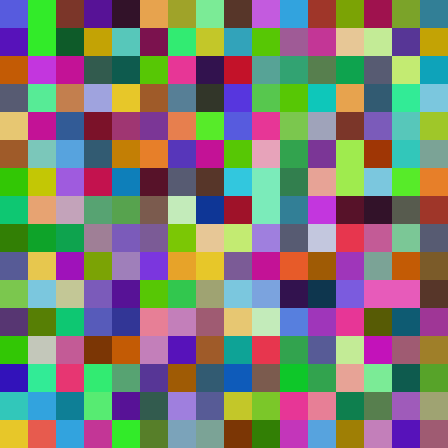

preview labels: /Users/choisoonwook/Experiments_local/Diffusion_HASH_inverse/output/conditional_diffusion_notebook/dataset_preview.labels.json
[
  {
    "index": 0,
    "file": "dataset_preview_000.png",
    "label": 131,
    "condition": "{\"1st Round\":{\"10th Loop\":{\"A\":\"0x7bd87f68\",\"B\":\"0xdec1058a\",\"C\":\"0x4decbfca\",\"D\":\"0x8da88f4a\"},\"11th Loop\":{\"A\":\"0x8da88f4a\",\"B\":\"0x64da7086\",\"C\":\"0xdec1058a\",\"D\":\"0x4decbfca\"},\"12th Loop\":{\"A\":\"0x4decbfca\",\"B\":\"0xd1325d70\",\"C\":\"0x64da7086\",\"D\":\"0xdec1058a\"},\"13th Loop\":{\"A\":\"0xdec1058a\",\"B\":\"0x09bb7ca9\",\"C\":\"0xd1325d70\",\"D\":\"0x64da7086\"},\"14th Loop\":{\"A\":\"0x64da7086\",\"B\":\"0xced7b9fd\",\"C\":\"0x09bb7ca9\",\"D\":\"0


In [5]:
def save_dataset_preview(
    dataset: GeneratedImageDataset,
    output_path: Path,
    count: int = 8,
) -> tuple[Path, list[Path], Path]:
    images = []
    labels = []
    for idx in range(min(count, len(dataset))):
        image, label = dataset[idx]
        images.append(image)
        labels.append(int(label))

    save_image_grid(
        torch.stack(images),
        torch.tensor(labels, dtype=torch.long),
        dataset.condition_names,
        output_path,
    )
    labels_path = output_path.with_suffix(".labels.json")
    saved_files = sorted(output_path.parent.glob(f"{output_path.stem}*.png"))
    return output_path, saved_files, labels_path


preview_base, preview_files, preview_labels = save_dataset_preview(
    dataset,
    NOTEBOOK_OUTPUT_DIR / "dataset_preview.png",
    4,
)
print("preview base:", preview_base)
print("preview files:", [path.name for path in preview_files])
display(Image.open(preview_files[0]))
print("preview labels:", preview_labels)
print(preview_labels.read_text(encoding=output_cfg.encoding)[:600])


## Smoke Training

This calls the same `train_conditional_diffusion` entry point used by the CLI.
When `save_process_traces=True`, forward trace progress is printed to stdout for every diffusion step.

In [6]:
RUN_SMOKE_TRAIN = False
if RUN_SMOKE_TRAIN:
    smoke_result = train_conditional_diffusion(smoke_config)
    print(smoke_result)
else:
    smoke_result = None
    print("Set RUN_SMOKE_TRAIN = True to start the smoke run.")


Set RUN_SMOKE_TRAIN = True to start the smoke run.


## Inspect Samples

The `.labels.json` file maps each saved sample PNG file to its `Logs/4th Step` condition label.

In [7]:
if smoke_result is None:
    print("Run the smoke training cell first by setting RUN_SMOKE_TRAIN = True.")
else:
    sample_base = Path(smoke_result["sample_grid"])
    sample_labels = sample_base.with_suffix(".labels.json")
    sample_files = sorted(sample_base.parent.glob(f"{sample_base.stem}*.png"))

    print("sample base:", sample_base)
    print("sample files:", [path.name for path in sample_files])
    for path in sample_files[:4]:
        display(Image.open(path))

    print("sample labels:", sample_labels)
    print(sample_labels.read_text(encoding=output_cfg.encoding)[:1000])


Run the smoke training cell first by setting RUN_SMOKE_TRAIN = True.


## Inspect Forward / Reverse Process Traces

Forward traces show noising from real dataset images for every timestep and the training cell stdout includes per-step `[forward-trace]` logs. Reverse traces show denoising from random noise for selected timesteps and condition labels.

In [8]:
if smoke_result is None:
    print("Run the smoke training cell first by setting RUN_SMOKE_TRAIN = True.")
else:
    trace_root = Path(smoke_result["process_traces"])
    forward_images = sorted((trace_root / "forward").glob("*.png"))
    reverse_images = sorted((trace_root / "reverse").glob("*.png"))

    beta_schedule = json.loads(Path(smoke_result["beta_schedule"]).read_text(encoding=output_cfg.encoding))
    effective_timesteps = int(beta_schedule["timesteps"])
    expected_forward = (effective_timesteps + 1) * smoke_config.trace_sample_count
    expected_reverse = (effective_timesteps + 1) * smoke_config.trace_sample_count

    print(f"forward trace files ({len(forward_images)} total, expected {expected_forward}):")
    for path in forward_images:
        print(" ", path.name)

    print(f"reverse trace files ({len(reverse_images)} total, expected {expected_reverse}):")
    for path in reverse_images:
        print(" ", path.name)

    display(Image.open(forward_images[0]))
    display(Image.open(reverse_images[0]))


Run the smoke training cell first by setting RUN_SMOKE_TRAIN = True.


In [9]:
import mlx.core as mx

def mem_cleanup(*names: str):
    for name in names:
        globals().pop(name, None)
    cleanup_torch_resources()

## Full Training Config

The full config is derived from the smoke config with `dataclasses.replace`, so only the values that differ are listed here.

In [ ]:
mem_cleanup("smoke_result", "dataset")
RUN_FULL_TRAIN = True

full_config = replace(
    smoke_config,
    output_dir=output_cfg.output_dir / "conditional_diffusion" / "Approach1",
    image_size=64,
    max_images=None,
    batch_size=32,
    train_steps=1000,
    epochs=1,
    timesteps=200,
    base_channels=64,
    time_dim=256,
    beta_schedule="hash-approach1",
    sample_count=16,
    save_process_traces=True,
    trace_sample_count=1,
    # trace_steps is compatibility-only; reverse traces are saved for all timesteps.
    save_train_batches_every=5,
    device="auto",
    log_every=50,
    sample_every=0,
    checkpoint_every=0,
)

if RUN_FULL_TRAIN:
    full_result = train_conditional_diffusion(full_config)
    print(full_result)
else:
    print("Set RUN_FULL_TRAIN = True to start the longer run.")
    asdict(full_config)

[reshape] mode=height-flatten source=7168x28 img_size=28x28 blocks=256 (16x16) output=448x448 channels=3
dataset=5000 images conditions=5000 steps=157 epochs=1 device=mps beta_schedule=hash-approach1 diffusion_timesteps=5280 sample_image_shape=(3, 448, 448) output=/Users/choisoonwook/Experiments_local/Diffusion_HASH_inverse/output/conditional_diffusion/Approach1
step=000001 loss=1.070879
saved train batch: /Users/choisoonwook/Experiments_local/Diffusion_HASH_inverse/output/conditional_diffusion/Approach1/train_batches/step_000005.png
saved train batch metadata: /Users/choisoonwook/Experiments_local/Diffusion_HASH_inverse/output/conditional_diffusion/Approach1/train_batches/step_000005.batch.json
saved train batch: /Users/choisoonwook/Experiments_local/Diffusion_HASH_inverse/output/conditional_diffusion/Approach1/train_batches/step_000010.png
saved train batch metadata: /Users/choisoonwook/Experiments_local/Diffusion_HASH_inverse/output/conditional_diffusion/Approach1/train_batches/step

In [13]:
mem_cleanup("full_result", "full_config")

In [ ]:
RUN_FULL_TRAIN = True

full_config = replace(
    smoke_config,
    output_dir=output_cfg.output_dir / "conditional_diffusion" / "Approach2",
    image_size=64,
    max_images=None,
    batch_size=32,
    train_steps=1000,
    epochs=1,
    timesteps=200,
    base_channels=64,
    time_dim=256,
    beta_schedule="hash-approach2",
    sample_count=16,
    save_process_traces=True,
    trace_sample_count=1,
    # trace_steps is compatibility-only; reverse traces are saved for all timesteps.
    save_train_batches_every=5,
    device="auto",
    log_every=50,
    sample_every=0,
    checkpoint_every=0,
)

if RUN_FULL_TRAIN:
    full_result = train_conditional_diffusion(full_config)
    print(full_result)
else:
    print("Set RUN_FULL_TRAIN = True to start the longer run.")
    asdict(full_config)


Set RUN_FULL_TRAIN = True to start the longer run.


In [ ]:
mem_cleanup("full_result", "full_config")

In [ ]:
RUN_FULL_TRAIN = True

full_config = replace(
    smoke_config,
    output_dir=output_cfg.output_dir / "conditional_diffusion" / "Linear",
    image_size=64,
    max_images=None,
    batch_size=32,
    train_steps=1000,
    epochs=1,
    timesteps="auto",
    base_channels=64,
    time_dim=256,
    beta_schedule="linear",
    sample_count=16,
    save_process_traces=True,
    trace_sample_count=1,
    # trace_steps is compatibility-only; reverse traces are saved for all timesteps.
    save_train_batches_every=5,
    device="auto",
    log_every=50,
    sample_every=0,
    checkpoint_every=0,
)

if RUN_FULL_TRAIN:
    full_result = train_conditional_diffusion(full_config)
    print(full_result)
else:
    print("Set RUN_FULL_TRAIN = True to start the longer run.")
    asdict(full_config)



Set RUN_FULL_TRAIN = True to start the longer run.


In [ ]:
mem_cleanup("full_result", "full_config")